In [2]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [3]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [4]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [5]:
ws_dict = fn.load_reanalysis_wind_speed(FILEPATH)

In [6]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Notable droughts
- 2010: https://wattclarity.com/articles/2022/06/seasons-of-low-wind-and-solar-output-will-influence-the-shape-of-the-nem/
- 2017 and 2024: https://wattclarity.com.au/articles/2024/07/09july-q2-wind-yield/

In [7]:
def sel_and_reindex(da, time):
    """
    Return selected array without timestamps

    da: array
    time: time selector for xarray array e.g. slice, string
    """
    da = da.sel(time=time)
    da["time"] = range(len(da["time"]))
    return da

In [8]:
def plot_ts_year_comparison(ax, da, time, roll, q, color="tab:blue", label="", title="", fill_between=True):
    """
    Time series plot of data

    ax: axes to plot on
    da: array
    time: time selector for xarray array e.g. slice, string
    roll: int, number of time steps in rolling average
    q: quantile, drought definition
    color: str, color of line
    label: str, line label
    title: str, plot title
    """
    # rolling mean
    da_roll = da.rolling(time=roll).mean()

    # drought threshold
    da_q = da_roll.quantile(q, "time")
    
    # Select dates to plot
    da_plot = sel_and_reindex(da_roll, time)

    # plot
    da_plot.plot(ax=ax, color=color, label=label, zorder=0)
    if fill_between:
        ax.fill_between(
            da_plot.time, y1=da_plot, y2=da_q, where=(da_plot < da_q), interpolate=True, color=color, alpha=0.5, zorder=1
        )
    ax.axhline(da_q, color=color)
    ax.set_title(title, fontsize=10)

In [44]:
years = ["2010", "2017", "2024"]

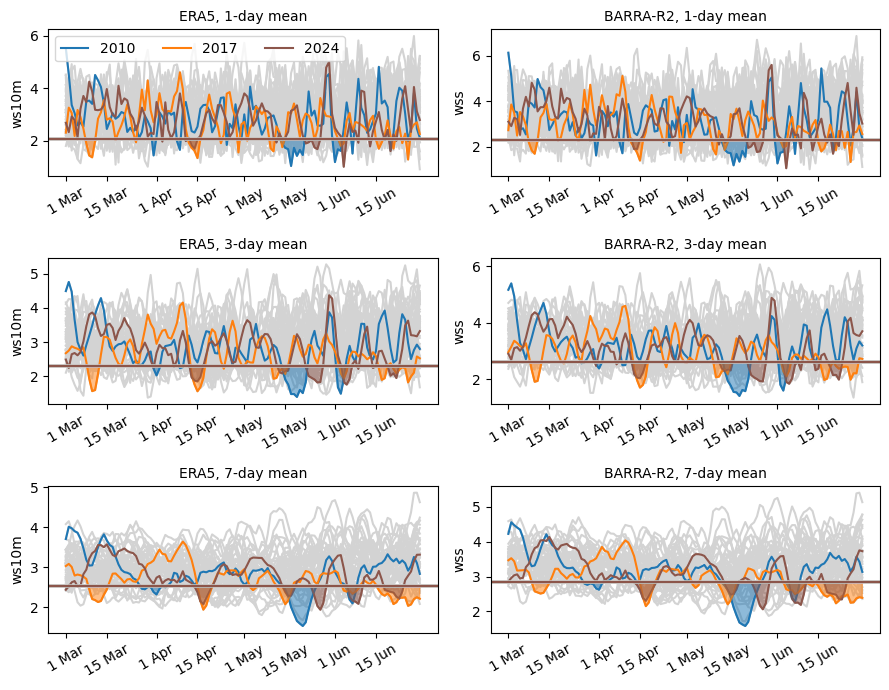

In [45]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7))

datasets = {"ERA5": "ws10m", "BARRA-R2": "wss"}
rolls = [1, 3, 7]
all_years = [str(i) for i in range(1979, 2025)]

for i, roll in enumerate(rolls):

    for j, year in enumerate(all_years):
        time = slice("03-"+year, "06-"+year)
        d = pd.date_range("03-"+year, "30-06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color="lightgray",
                fill_between=False
            )
    
    for j, (year, color) in enumerate(zip(
        years, ["tab:blue", "tab:orange", "tab:brown"]#, "tab:green", "tab:pink"]
        # years, ["tab:blue", "tab:orange", "tab:brown", "tab:green", "tab:pink"]
    )):
        time = slice("03-"+year, "06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color=color,
                label=year,
                title=dataset+", "+str(roll)+"-day mean"
            )

ax[0,0].legend(ncols=3)
for a in ax.flatten():
    a.set_xlabel("")
    a.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    a.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ], rotation=30)
plt.tight_layout()

In [46]:
da = fn.sel_month(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"],
    [3, 4, 5, 6]
)

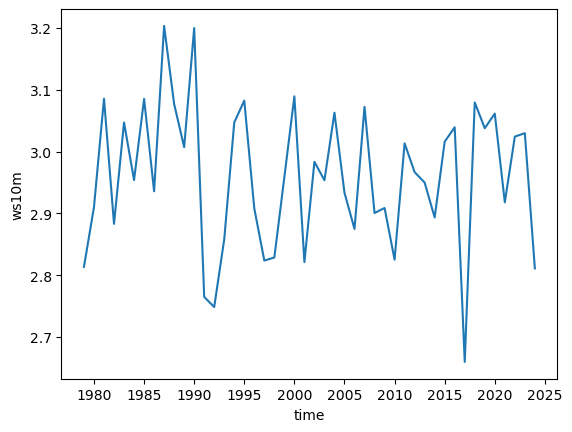

In [47]:
da.resample(time="1YS").mean().plot()

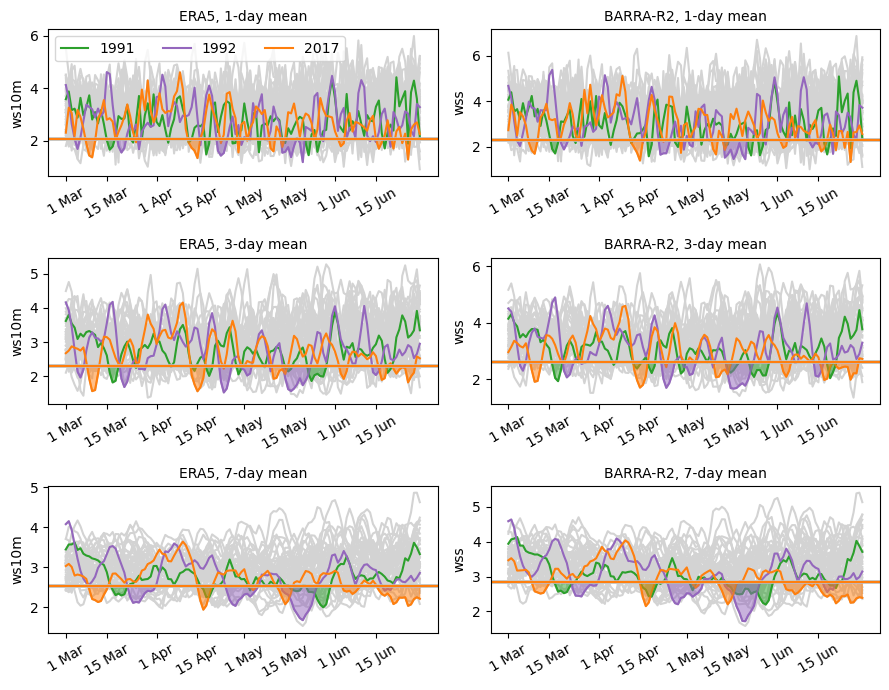

In [49]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7))

years = ["1991", "1992", "2017"]
datasets = {"ERA5": "ws10m", "BARRA-R2": "wss"}
rolls = [1, 3, 7]
all_years = [str(i) for i in range(1979, 2025)]

for i, roll in enumerate(rolls):

    for j, year in enumerate(all_years):
        time = slice("03-"+year, "06-"+year)
        d = pd.date_range("03-"+year, "30-06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color="lightgray",
                fill_between=False
            )
    
    for j, (year, color) in enumerate(zip(
        years, ["tab:green", "tab:purple", "tab:orange"]#, "tab:green", "tab:pink"]
        # years, ["tab:blue", "tab:orange", "tab:brown", "tab:green", "tab:pink"]
    )):
        time = slice("03-"+year, "06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color=color,
                label=year,
                title=dataset+", "+str(roll)+"-day mean"
            )

ax[0,0].legend(ncols=3)
for a in ax.flatten():
    a.set_xlabel("")
    a.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    a.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ], rotation=30)
plt.tight_layout()

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [6]:
def cumsum_reset_on_mask(data, mask, dim="time"):
    """
    Cumulative sum of `data` along `dim`, resetting to zero wherever `mask` == 0.
    
    Parameters
    ----------
    data : xr.DataArray
        Array to accumulate.
    mask : xr.DataArray
        Binary array of the same shape, where 0 means "reset".
    dim : str
        Dimension along which to accumulate (default: "time").
        
    Returns
    -------
    xr.DataArray
        Same shape as `data`, cumulative sum with resets.
    """
    a = data.values
    reset = (mask.values == 0)

    out = np.zeros_like(a, dtype=float)

    axis = data.get_axis_num(dim)
    a = np.moveaxis(a, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)

    acc = np.zeros_like(a[0], dtype=float)
    for i in range(a.shape[0]):
        acc = np.where(reset[i], 0, acc + a[i])
        out[i] = acc

    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=data.coords, dims=data.dims, attrs=data.attrs)


In [7]:
DROUGHT_Q = 0.1

In [8]:
for k,v in ws_dict.items():
    ws_dict[k] = v.to_dataset(name=v.name)
    ds = ws_dict[k]

    # Compute drought days and cumulative lengths
    drought_days = xr.where(v < v.quantile(DROUGHT_Q, "time"), 1, 0)
    drought_sum = cumsum_reset_on_mask(drought_days, drought_days).astype("int")

    # Accumulate wind speed anomalies over drought days
    ws_clim = v.mean("time")
    ws_anoms = v - ws_clim
    ws_severity = cumsum_reset_on_mask(ws_anoms, drought_days)
    
    # ds["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    # ds["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

    ws_dict[k]["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    ws_dict[k]["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

### Drought metrics

Number of drought days per year

In [61]:
def n_drought_days(da):
    """
    Return number of drought days per year
    """
    # return da.resample(time="1YS").sum()
    return xr.where(da > 0, 1, 0).resample(time="1YS").sum()

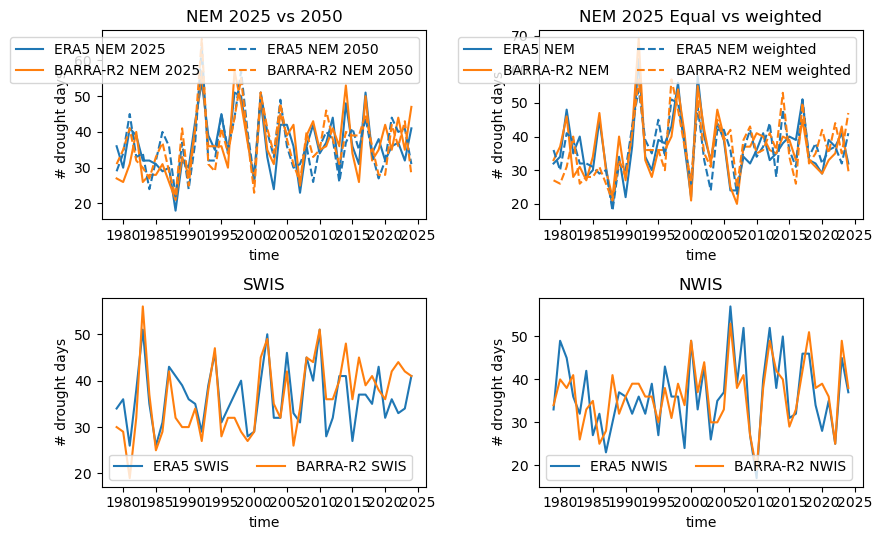

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(9, 5.5))

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[0,0], label="ERA5 NEM 2025")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[0,0], label="BARRA-R2 NEM 2025")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[0,0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[0,0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0,0].set_title("NEM 2025 vs 2050")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0,1], label="ERA5 NEM")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0,1], label="BARRA-R2 NEM")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[0,1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[0,1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[0,1].set_title("NEM 2025 Equal vs weighted")

n_drought_days(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[1,0], label="ERA5 SWIS")
n_drought_days(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[1,0], label="BARRA-R2 SWIS")
ax[1,0].set_title("SWIS")

n_drought_days(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[1,1], label="ERA5 NWIS")
n_drought_days(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[1,1], label="BARRA-R2 NWIS")
ax[1,1].set_title("NWIS")

for a in ax.flatten():
    a.set_ylabel("# drought days")
    a.legend(ncols=2)

plt.tight_layout()

Number of drought periods per year

In [11]:
def n_droughts(da, min_len=1):
    """
    Return number of droughts of a minimum length per year
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(da >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return xr.where(diff == -1, 1, 0).resample(time="1YS").sum()

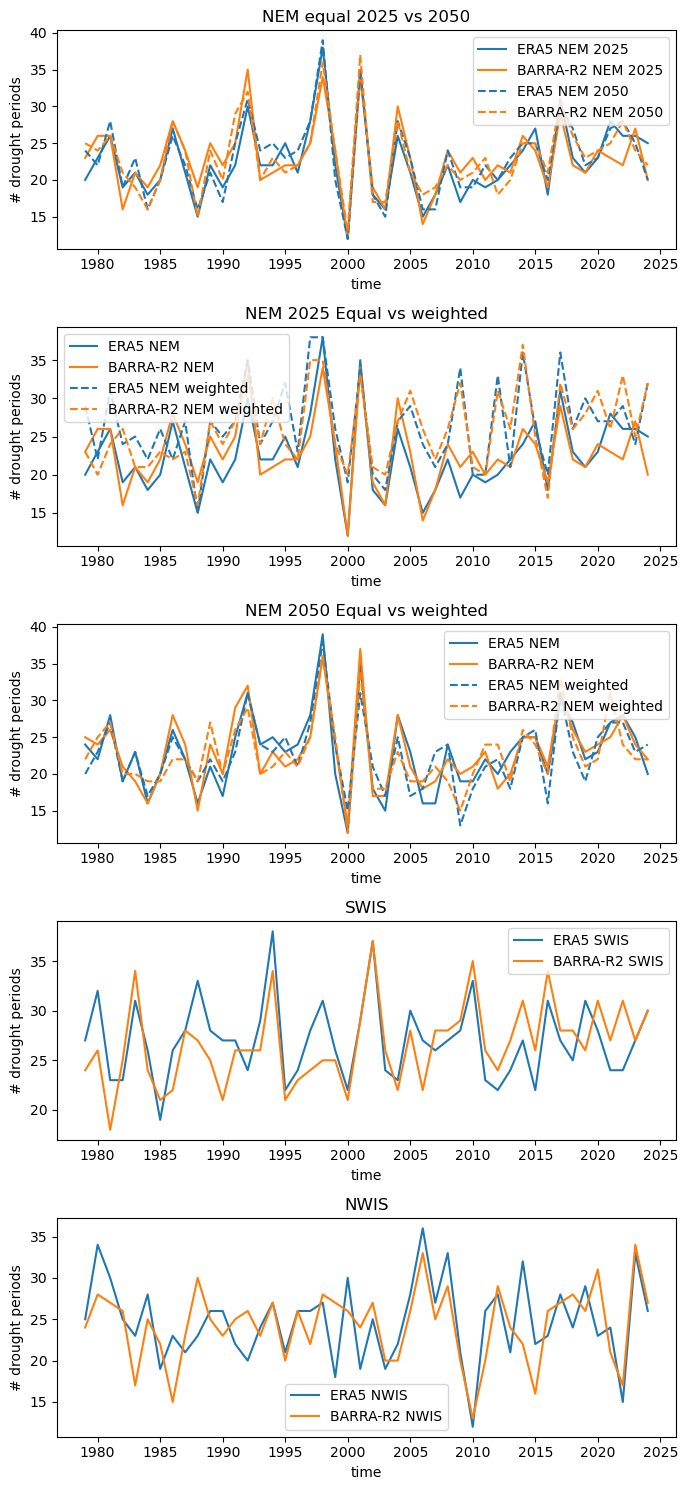

In [36]:
min_len = 1

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

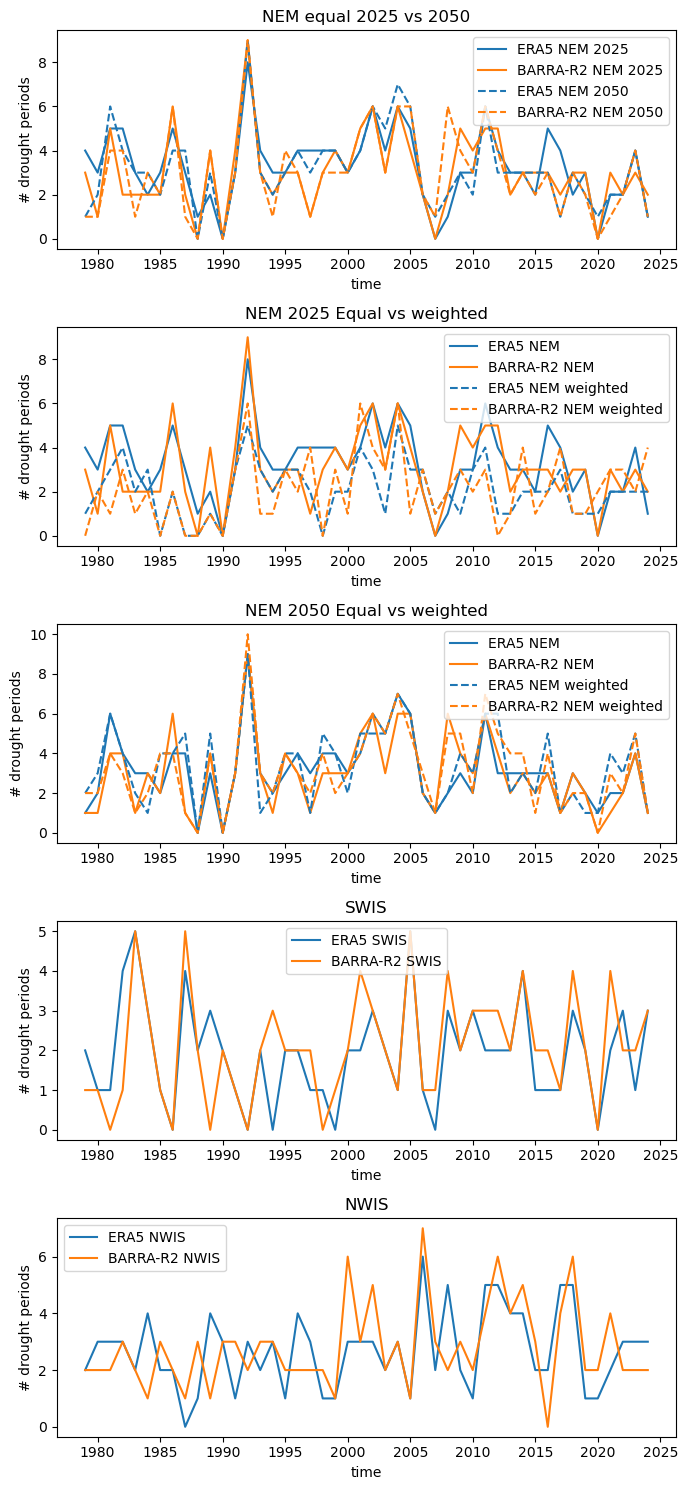

In [37]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

Longest drought per year

In [12]:
def longest_drought(da):
    """
    Return longest drought each year
    """
    return da.groupby("time.year").max()

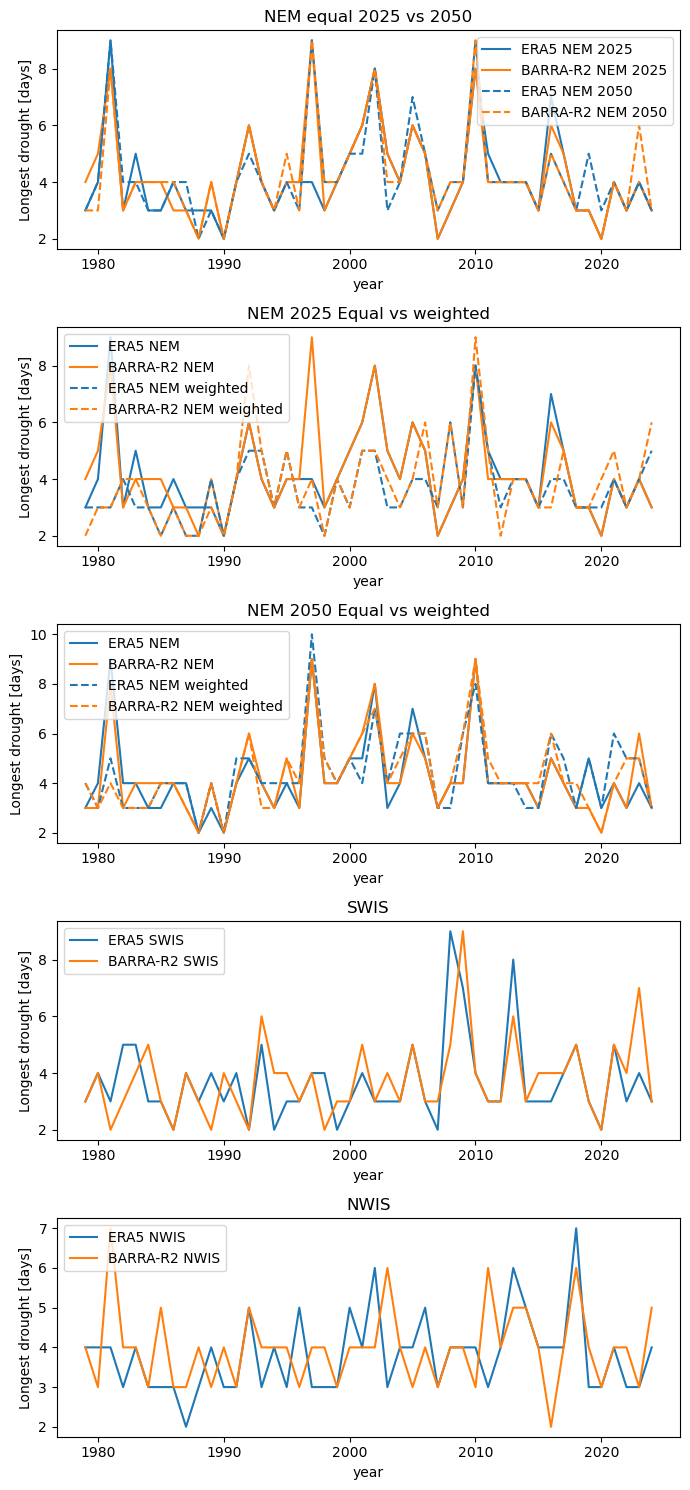

In [34]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
longest_drought(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

longest_drought(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
longest_drought(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Longest drought [days]")
    
plt.tight_layout()

Accumulated drought intensity

In [13]:
def max_intensity(da, mask, min_len=1):
    """
    Return annual max of drought intensity

    da: array of accumulated wind speed anomalies on drought days
    mask: array of drought periods
    min_len: int, minimum number of consecutive drought days per drought period
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(mask >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return da.where(diff == -1).resample(time="1YS").min()

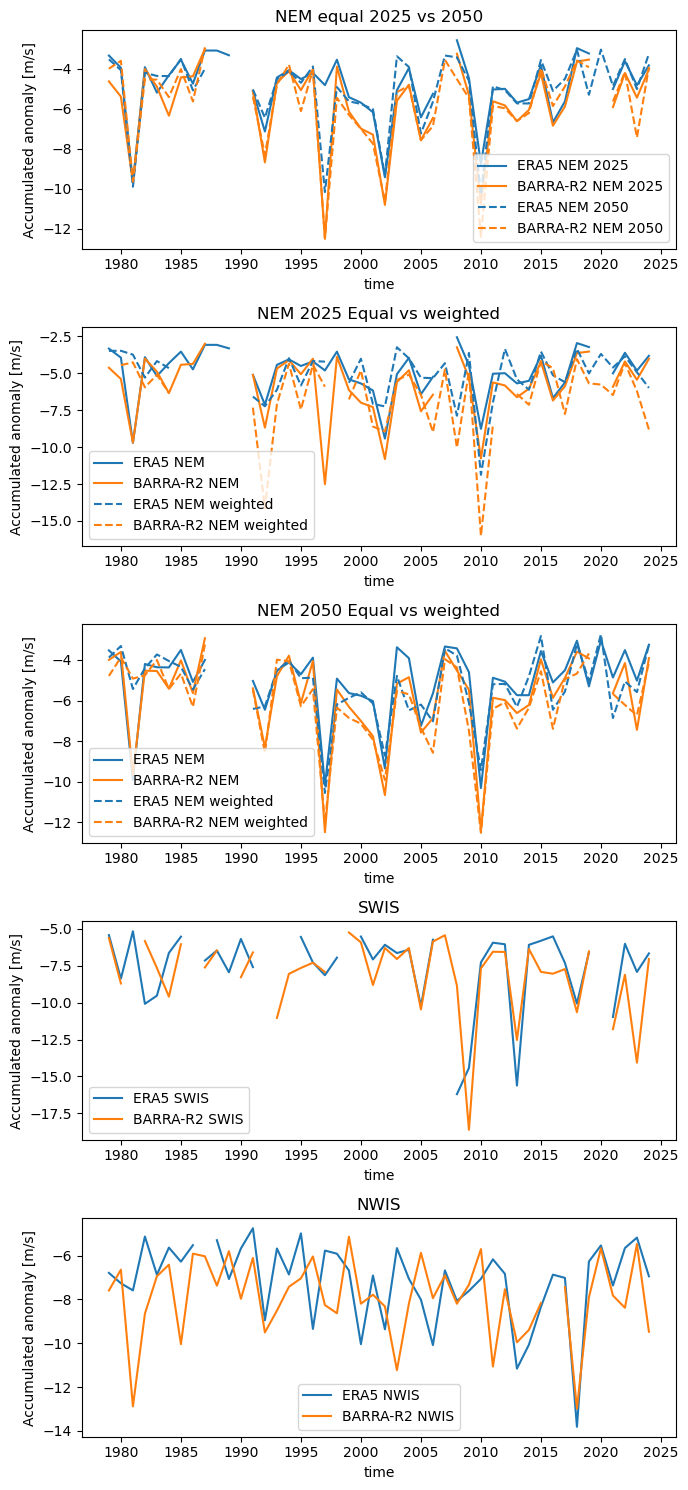

In [43]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_SWIS"]["drought_severity_p10"],
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
max_intensity(
    ws_dict["BARRA-R2_SWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

max_intensity(
    ws_dict["ERA5_NWIS"]["drought_severity_p10"],
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
max_intensity(
    ws_dict["BARRA-R2_NWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Accumulated anomaly [m/s]")
    
plt.tight_layout()